# RNN / LSTM 기반 영화 리뷰 감성 분류 통합 노트북

이 노트북은 업로드된 두 노트북의 장점을 합쳐서 정리한 버전입니다.

- `RNN+LSTM_problem1.ipynb`의 장점: 시드 고정, 층화 분리, Train 데이터 기준 SentencePiece 학습, 동적 `MAX_LEN`, `lengths` 기반 `pack_padded_sequence`, 함수화된 학습/평가 구조, Test 평가 및 Confusion Matrix
- `NLP_task_ipynb(과제_early_stopping)의_사본.ipynb`의 장점: 단계별 설명 흐름, 데이터 샘플 확인, `Early Stopping`, 직관적인 학습 로그

최종 구조는 **데이터 로드 → 층화 분리 → SentencePiece 학습 → 토큰화/패딩 → Dataset/DataLoader → RNN/LSTM 모델 → Early Stopping 학습 → Test 평가** 순서입니다.

## 0. 필요한 패키지 설치

처음 실행하는 환경이면 아래 셀을 실행하세요. 이미 설치되어 있으면 다시 실행하지 않아도 됩니다.

## 1. 라이브러리 불러오기

NLP 데이터 처리, SentencePiece 토큰화, PyTorch 모델 학습, 평가 지표 출력을 위한 라이브러리를 불러옵니다.

In [1]:
import os
import random
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import movie_reviews

import sentencepiece as spm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

## 2. 랜덤 시드 고정

랜덤 시드를 고정하는 이유는 실행할 때마다 데이터 분리, 초기 가중치, 셔플 순서가 달라지는 문제를 줄이기 위해서입니다.
완전히 같은 결과를 보장하지는 않더라도, 실험 재현성을 높일 수 있습니다.

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# 가능한 범위에서 재현성 강화
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("SEED:", SEED)

SEED: 42


## 3. NLTK Movie Reviews 데이터 로드

`movie_reviews` 데이터셋은 긍정(`pos`) / 부정(`neg`) 영화 리뷰로 구성된 이진 감성 분류 데이터입니다.

모델은 문자열을 직접 이해하지 못하므로, 이후 SentencePiece를 이용해 리뷰 텍스트를 정수 토큰 ID로 변환합니다.

In [3]:
nltk.download("movie_reviews")

texts = []
labels = []
label_map = {"neg": 0, "pos": 1}

for category in movie_reviews.categories():
    for file_id in movie_reviews.fileids(category):
        text = movie_reviews.raw(file_id).replace("\n", " ").strip()
        texts.append(text)
        labels.append(label_map[category])

texts = np.array(texts)
labels = np.array(labels)

print("전체 데이터 수:", len(texts))
print("라벨 종류:", np.unique(labels))
print("라벨 분포:", Counter(labels))
print("샘플 텍스트 앞부분:\n", texts[0][:500])
print("샘플 라벨:", labels[0])

[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Unzipping corpora/movie_reviews.zip.


전체 데이터 수: 2000
라벨 종류: [0 1]
라벨 분포: Counter({np.int64(0): 1000, np.int64(1): 1000})
샘플 텍스트 앞부분:
 plot : two teen couples go to a church party , drink and then drive .  they get into an accident .  one of the guys dies , but his girlfriend continues to see him in her life , and has nightmares .  what's the deal ?  watch the movie and " sorta " find out . . .  critique : a mind-fuck movie for the teen generation that touches on a very cool idea , but presents it in a very bad package .  which is what makes this review an even harder one to write , since i generally applaud films which attempt
샘플 라벨: 0


## 4. Train / Validation / Test 데이터 분리

여기서는 전체 데이터를 다음 비율로 나눕니다.

- Train: 72%
- Validation: 18%
- Test: 10%

`stratify`를 사용하는 이유는 긍정/부정 라벨 비율이 Train, Validation, Test에 비슷하게 유지되도록 하기 위해서입니다.  
감성 분류처럼 라벨 균형이 중요한 문제에서는 단순 랜덤 분리보다 안정적입니다.

In [4]:
# 1차 분리: Train+Validation / Test
x_train_val, x_test, y_train_val, y_test = train_test_split(
    texts,
    labels,
    test_size=0.1,
    random_state=SEED,
    stratify=labels
)

# 2차 분리: Train / Validation
x_train, x_val, y_train, y_val = train_test_split(
    x_train_val,
    y_train_val,
    test_size=0.2,
    random_state=SEED,
    stratify=y_train_val
)

print("x_train:", x_train.shape, "라벨 분포:", Counter(y_train))
print("x_val  :", x_val.shape, "라벨 분포:", Counter(y_val))
print("x_test :", x_test.shape, "라벨 분포:", Counter(y_test))

x_train: (1440,) 라벨 분포: Counter({np.int64(0): 720, np.int64(1): 720})
x_val  : (360,) 라벨 분포: Counter({np.int64(1): 180, np.int64(0): 180})
x_test : (200,) 라벨 분포: Counter({np.int64(0): 100, np.int64(1): 100})


## 5. SentencePiece 단어사전 학습

SentencePiece는 문장을 서브워드 단위로 나누는 토크나이저입니다.

중요한 점은 **단어사전은 Train 데이터로만 학습**한다는 것입니다.  
Validation/Test 데이터까지 사용해서 단어사전을 만들면, 평가 데이터의 정보가 학습 과정에 미리 들어가는 데이터 누수 문제가 생길 수 있습니다.

In [5]:
ARTIFACT_DIR = "artifacts"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

SPM_TRAIN_FILE = os.path.join(ARTIFACT_DIR, "spm_train_texts.txt")
SPM_MODEL_PREFIX = os.path.join(ARTIFACT_DIR, "movie_review_unigram")
SPM_MODEL_FILE = SPM_MODEL_PREFIX + ".model"

VOCAB_SIZE = 8000

with open(SPM_TRAIN_FILE, "w", encoding="utf-8") as f:
    for text in x_train:
        clean_text = str(text).replace("\n", " ").strip()
        f.write(clean_text + "\n")

spm.SentencePieceTrainer.train(
    input=SPM_TRAIN_FILE,
    model_prefix=SPM_MODEL_PREFIX,
    vocab_size=VOCAB_SIZE,
    model_type="unigram",
    pad_id=0,
    unk_id=1,
    bos_id=2,
    eos_id=3,
    character_coverage=1.0,
    hard_vocab_limit=False
)

print("SentencePiece 모델 저장 완료:", SPM_MODEL_FILE)

SentencePiece 모델 저장 완료: artifacts/movie_review_unigram.model


## 6. 토큰화와 `MAX_LEN` 설정

모든 문장을 같은 길이로 맞추기 위해 Padding을 적용합니다.

다만 무조건 너무 큰 길이로 맞추면 계산량이 낭비됩니다.  
그래서 Train 데이터 토큰 길이의 95퍼센타일을 기준으로 `MAX_LEN`을 정합니다.

- 너무 긴 리뷰: `MAX_LEN`까지만 자름
- 짧은 리뷰: `PAD_ID`로 뒤를 채움
- 실제 길이: `lengths`에 따로 저장해서 RNN/LSTM이 PAD를 무시하도록 사용

In [6]:
sp = spm.SentencePieceProcessor()
sp.load(SPM_MODEL_FILE)

PAD_ID = sp.pad_id()
UNK_ID = sp.unk_id()
VOCAB_SIZE = sp.get_piece_size()

train_token_lengths = []
for text in x_train:
    token_ids = sp.encode(str(text), out_type=int)
    if len(token_ids) == 0:
        token_ids = [UNK_ID]
    train_token_lengths.append(len(token_ids))

MAX_LEN_PERCENTILE = 95
MAX_LEN_UPPER_BOUND = 1024
MAX_LEN = int(np.percentile(train_token_lengths, MAX_LEN_PERCENTILE))
MAX_LEN = min(MAX_LEN, MAX_LEN_UPPER_BOUND)
MAX_LEN = max(MAX_LEN, 1)

print("PAD_ID:", PAD_ID)
print("UNK_ID:", UNK_ID)
print("실제 VOCAB_SIZE:", VOCAB_SIZE)
print("MAX_LEN:", MAX_LEN)
print("Train 토큰 길이 평균:", np.mean(train_token_lengths))
print("Train 토큰 길이 95퍼센타일:", np.percentile(train_token_lengths, 95))

PAD_ID: 0
UNK_ID: 1
실제 VOCAB_SIZE: 8000
MAX_LEN: 1024
Train 토큰 길이 평균: 970.1611111111112
Train 토큰 길이 95퍼센타일: 1793.05


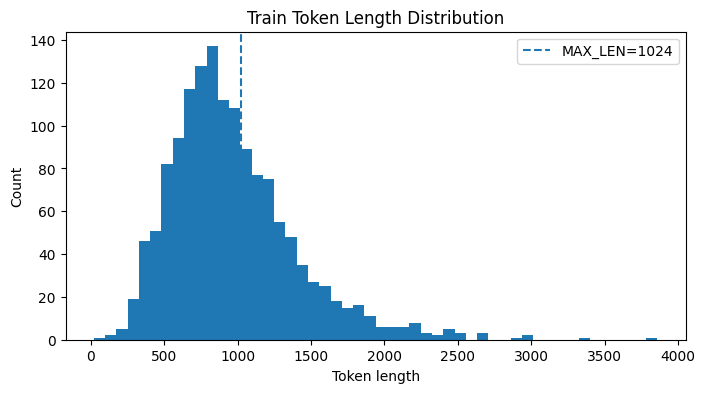

In [7]:
plt.figure(figsize=(8, 4))
plt.hist(train_token_lengths, bins=50)
plt.axvline(MAX_LEN, linestyle="--", label=f"MAX_LEN={MAX_LEN}")
plt.title("Train Token Length Distribution")
plt.xlabel("Token length")
plt.ylabel("Count")
plt.legend()
plt.show()

## 7. 인코딩 함수 작성

`encode_pad()`는 하나의 문장을 다음 세 가지 정보로 바꿉니다.

1. `token_ids`: 패딩까지 적용된 정수 토큰 ID 목록
2. `length`: 패딩을 제외한 실제 토큰 길이
3. `label`: 정답 라벨

`length`를 따로 저장하는 이유는 RNN/LSTM에서 `pack_padded_sequence`를 사용하기 위해서입니다.

In [8]:
def encode_pad(text, max_len=MAX_LEN):
    token_ids = sp.encode(str(text), out_type=int)

    if len(token_ids) == 0:
        token_ids = [UNK_ID]

    length = min(len(token_ids), max_len)

    token_ids = token_ids[:max_len]
    padding_size = max_len - len(token_ids)
    token_ids = token_ids + [PAD_ID] * padding_size

    return token_ids, length


def encode_dataset(x_data, y_data):
    x_encoded = []
    lengths = []

    for text in x_data:
        token_ids, length = encode_pad(text)
        x_encoded.append(token_ids)
        lengths.append(length)

    x_tensor = torch.tensor(x_encoded, dtype=torch.long)
    y_tensor = torch.tensor(y_data, dtype=torch.long)
    lengths_tensor = torch.tensor(lengths, dtype=torch.long)

    return x_tensor, y_tensor, lengths_tensor

x_train_tensor, y_train_tensor, train_lengths = encode_dataset(x_train, y_train)
x_val_tensor, y_val_tensor, val_lengths = encode_dataset(x_val, y_val)
x_test_tensor, y_test_tensor, test_lengths = encode_dataset(x_test, y_test)

print("Train X:", x_train_tensor.shape, "Train y:", y_train_tensor.shape, "lengths:", train_lengths.shape)
print("Val   X:", x_val_tensor.shape, "Val   y:", y_val_tensor.shape, "lengths:", val_lengths.shape)
print("Test  X:", x_test_tensor.shape, "Test  y:", y_test_tensor.shape, "lengths:", test_lengths.shape)

Train X: torch.Size([1440, 1024]) Train y: torch.Size([1440]) lengths: torch.Size([1440])
Val   X: torch.Size([360, 1024]) Val   y: torch.Size([360]) lengths: torch.Size([360])
Test  X: torch.Size([200, 1024]) Test  y: torch.Size([200]) lengths: torch.Size([200])


## 8. Dataset / DataLoader 생성

`Dataset`은 하나의 샘플을 꺼내는 방식을 정의하고, `DataLoader`는 여러 샘플을 Batch 단위로 묶어 모델에 넣어줍니다.

여기서는 `(토큰 ID, 라벨, 실제 길이)`를 함께 반환합니다.

In [9]:
class MovieReviewDataset(Dataset):
    def __init__(self, x_data, labels, lengths):
        self.x_data = x_data
        self.labels = labels
        self.lengths = lengths

    def __getitem__(self, index):
        return self.x_data[index], self.labels[index], self.lengths[index]

    def __len__(self):
        return len(self.labels)


train_dataset = MovieReviewDataset(x_train_tensor, y_train_tensor, train_lengths)
val_dataset = MovieReviewDataset(x_val_tensor, y_val_tensor, val_lengths)
test_dataset = MovieReviewDataset(x_test_tensor, y_test_tensor, test_lengths)

sample_x, sample_y, sample_len = train_dataset[0]
print("샘플 X shape:", sample_x.shape)
print("샘플 y:", sample_y)
print("샘플 실제 길이:", sample_len)
print("샘플 토큰 앞부분:", sample_x[:30])

샘플 X shape: torch.Size([1024])
샘플 y: tensor(0)
샘플 실제 길이: tensor(1024)
샘플 토큰 앞부분: tensor([   5, 2963, 1173,   29,   30,   31,   13,   77,   18,   68,  507,    4,
          42,   72,   14, 1384,  151,   18,    7,   60,   32,  211,   40,   12,
          23,  416,  131,  105,   14,   50])


In [10]:
BATCH_SIZE = 32

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pin_memory = device.type == "cuda"

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=pin_memory
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=pin_memory
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=pin_memory
)

print("사용 device:", device)
print("Train Batch 개수:", len(train_loader))
print("Validation Batch 개수:", len(val_loader))
print("Test Batch 개수:", len(test_loader))

사용 device: cuda
Train Batch 개수: 45
Validation Batch 개수: 12
Test Batch 개수: 7


## 9. RNN / LSTM 모델 정의

이 셀은 RNN과 LSTM을 모두 선택할 수 있게 만든 통합 모델입니다.

- `MODEL_TYPE = "rnn"`: 기본 RNN 사용
- `MODEL_TYPE = "lstm"`: LSTM 사용

두 원본 노트북은 실제 코드 기준으로 RNN만 구현되어 있었지만, 첫 번째 파일명이 `RNN+LSTM`이므로 실험 확장성을 위해 LSTM도 선택 가능하게 넣었습니다.

`pack_padded_sequence`를 쓰는 이유는 Padding 토큰이 RNN/LSTM의 hidden state 계산에 영향을 주지 않게 하기 위해서입니다.

In [11]:
class RecurrentTextClassifier(nn.Module):
    def __init__(
        self,
        vocab_size,
        embedding_dim,
        hidden_dim,
        output_dim,
        pad_id,
        model_type="rnn",
        num_layers=1,
        bidirectional=False,
        dropout=0.5
    ):
        super().__init__()

        model_type = model_type.lower()
        if model_type not in {"rnn", "lstm"}:
            raise ValueError("model_type은 'rnn' 또는 'lstm'만 가능합니다.")

        self.model_type = model_type
        self.bidirectional = bidirectional

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=pad_id
        )

        self.embedding_dropout = nn.Dropout(dropout)

        rnn_dropout = dropout if num_layers > 1 else 0.0
        rnn_class = nn.RNN if model_type == "rnn" else nn.LSTM

        self.encoder = rnn_class(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=rnn_dropout
        )

        fc_input_dim = hidden_dim * 2 if bidirectional else hidden_dim
        self.fc = nn.Linear(fc_input_dim, output_dim)

    def forward(self, x, lengths):
        embedded = self.embedding(x)
        embedded = self.embedding_dropout(embedded)

        packed_embedded = nn.utils.rnn.pack_padded_sequence(
            embedded,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )

        if self.model_type == "lstm":
            _, (hidden, _) = self.encoder(packed_embedded)
        else:
            _, hidden = self.encoder(packed_embedded)

        if self.bidirectional:
            # 마지막 layer의 forward/backward hidden state 결합
            last_hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)
        else:
            last_hidden = hidden[-1]

        logits = self.fc(last_hidden)
        return logits

## 10. 모델, Loss Function, Optimizer 설정

이진 분류는 보통 두 가지 방식 중 하나를 사용합니다.

1. 출력 뉴런 1개 + `BCEWithLogitsLoss`
2. 출력 뉴런 2개 + `CrossEntropyLoss`

여기서는 `CrossEntropyLoss`를 사용합니다.  
이유는 부정/긍정 두 클래스를 명확하게 `0`, `1` 라벨로 두고 `argmax`로 예측 클래스를 구하는 흐름이 평가 코드와 잘 맞기 때문입니다.

In [12]:
MODEL_TYPE = "lstm"      # "rnn" 또는 "lstm"
EMBEDDING_DIM = 128
HIDDEN_DIM = 128
OUTPUT_DIM = 2
NUM_LAYERS = 1
BIDIRECTIONAL = False
DROPOUT = 0.5
LEARNING_RATE = 3e-4

model = RecurrentTextClassifier(
    vocab_size=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    output_dim=OUTPUT_DIM,
    pad_id=PAD_ID,
    model_type=MODEL_TYPE,
    num_layers=NUM_LAYERS,
    bidirectional=BIDIRECTIONAL,
    dropout=DROPOUT
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(model)
print("Loss Function:", criterion)
print("Optimizer:", optimizer)

RecurrentTextClassifier(
  (embedding): Embedding(8000, 128, padding_idx=0)
  (embedding_dropout): Dropout(p=0.5, inplace=False)
  (encoder): LSTM(128, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=2, bias=True)
)
Loss Function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0003
    maximize: False
    weight_decay: 0
)


## 11. 학습 함수와 평가 함수

학습과 평가를 함수로 분리하면 코드 중복이 줄어들고, Test 평가에도 같은 평가 함수를 재사용할 수 있습니다.

- `train_one_epoch()`: 모델 학습, 역전파, 파라미터 업데이트 수행
- `evaluate()`: 기울기 계산 없이 Loss, Accuracy, 예측값 계산

In [13]:
def train_one_epoch(model, data_loader, criterion, optimizer, device, clip_norm=1.0):
    model.train()

    total_loss = 0.0
    correct = 0
    total = 0

    for x_batch, y_batch, lengths_batch in data_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        lengths_batch = lengths_batch.to(device)

        optimizer.zero_grad()

        outputs = model(x_batch, lengths_batch)
        loss = criterion(outputs, y_batch)

        loss.backward()

        if clip_norm is not None:
            nn.utils.clip_grad_norm_(model.parameters(), clip_norm)

        optimizer.step()

        batch_size = y_batch.size(0)
        total_loss += loss.item() * batch_size

        preds = torch.argmax(outputs, dim=1)
        correct += (preds == y_batch).sum().item()
        total += batch_size

    avg_loss = total_loss / total
    accuracy = correct / total

    return avg_loss, accuracy


def evaluate(model, data_loader, criterion, device):
    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for x_batch, y_batch, lengths_batch in data_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            lengths_batch = lengths_batch.to(device)

            outputs = model(x_batch, lengths_batch)
            loss = criterion(outputs, y_batch)

            batch_size = y_batch.size(0)
            total_loss += loss.item() * batch_size

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == y_batch).sum().item()
            total += batch_size

            all_preds.extend(preds.cpu().numpy().tolist())
            all_labels.extend(y_batch.cpu().numpy().tolist())

    avg_loss = total_loss / total
    accuracy = correct / total

    return avg_loss, accuracy, all_preds, all_labels

## 12. Early Stopping을 적용한 모델 학습

Early Stopping은 Validation Loss가 더 이상 좋아지지 않을 때 학습을 중단하는 방식입니다.

왜 쓰는가?

- Epoch를 너무 많이 돌려서 Train 데이터에 과적합되는 것을 줄일 수 있음
- 성능이 좋아지지 않는 학습을 계속하지 않아 시간 낭비를 줄일 수 있음
- 가장 Validation Loss가 낮았던 모델을 저장해 Test 평가에 사용 가능

In [14]:
MAX_EPOCHS = 50
PATIENCE = 5
MIN_DELTA = 0.0
BEST_MODEL_PATH = os.path.join(ARTIFACT_DIR, f"best_{MODEL_TYPE}_movie_review.pt")

best_val_loss = float("inf")
patience_counter = 0
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

for epoch in range(1, MAX_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(
        model=model,
        data_loader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        clip_norm=1.0
    )

    val_loss, val_acc, _, _ = evaluate(
        model=model,
        data_loader=val_loader,
        criterion=criterion,
        device=device
    )

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch [{epoch:02d}/{MAX_EPOCHS}]")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")

    if val_loss < best_val_loss - MIN_DELTA:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print("Validation Loss 개선: Best model saved")
    else:
        patience_counter += 1
        print(f"개선 없음: {patience_counter}/{PATIENCE}")

        if patience_counter >= PATIENCE:
            print("Early Stopping 발동: 학습 중단")
            break

    print("-" * 60)

print("학습 종료")
print("Best Validation Loss:", best_val_loss)
print("Best Model Path:", BEST_MODEL_PATH)

Epoch [01/50]
Train Loss: 0.6926 | Train Acc: 0.5278
Val   Loss: 0.6916 | Val   Acc: 0.5139
Validation Loss 개선: Best model saved
------------------------------------------------------------
Epoch [02/50]
Train Loss: 0.6874 | Train Acc: 0.5521
Val   Loss: 0.6898 | Val   Acc: 0.5417
Validation Loss 개선: Best model saved
------------------------------------------------------------
Epoch [03/50]
Train Loss: 0.6833 | Train Acc: 0.5771
Val   Loss: 0.6881 | Val   Acc: 0.5472
Validation Loss 개선: Best model saved
------------------------------------------------------------
Epoch [04/50]
Train Loss: 0.6753 | Train Acc: 0.5875
Val   Loss: 0.6869 | Val   Acc: 0.5417
Validation Loss 개선: Best model saved
------------------------------------------------------------
Epoch [05/50]
Train Loss: 0.6708 | Train Acc: 0.5861
Val   Loss: 0.6856 | Val   Acc: 0.5500
Validation Loss 개선: Best model saved
------------------------------------------------------------
Epoch [06/50]
Train Loss: 0.6648 | Train Acc: 0.59

## 13. 학습 곡선 확인

Train Loss와 Validation Loss를 같이 보면 과적합 여부를 확인할 수 있습니다.

- Train Loss는 계속 감소하는데 Validation Loss가 증가하면 과적합 가능성이 큼
- 둘 다 감소하면 학습이 정상적으로 진행되는 흐름

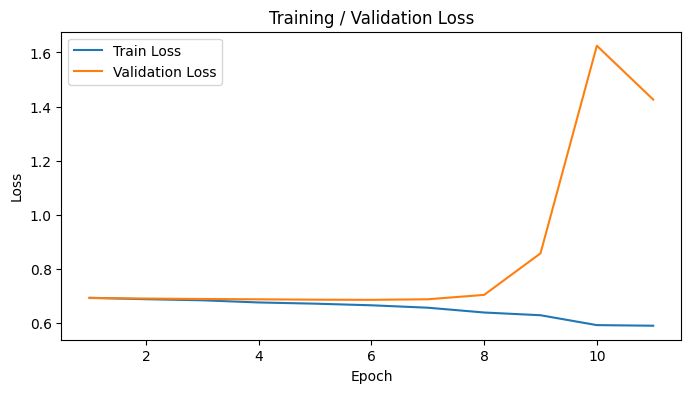

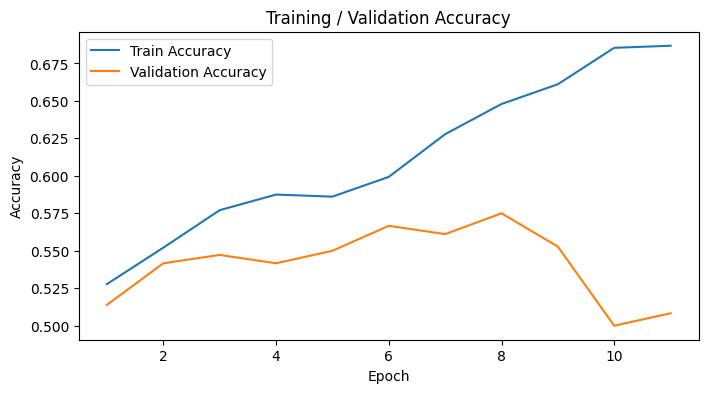

In [15]:
epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(8, 4))
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training / Validation Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(epochs, history["train_acc"], label="Train Accuracy")
plt.plot(epochs, history["val_acc"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training / Validation Accuracy")
plt.legend()
plt.show()

## 14. Test 데이터 평가

Validation 데이터는 학습 중 모델 선택에 사용했고, Test 데이터는 마지막 최종 성능 확인에만 사용합니다.

즉, Test Accuracy는 모델이 처음 보는 데이터에 대해 어느 정도 일반화되는지를 보는 지표입니다.

In [16]:
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
model.to(device)

print("Best model loaded")

test_loss, test_acc, test_preds, test_labels = evaluate(
    model=model,
    data_loader=test_loader,
    criterion=criterion,
    device=device
)

print("=" * 60)
print("Test Result")
print("=" * 60)
print(f"Test Loss    : {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print("=" * 60)

Best model loaded
Test Result
Test Loss    : 0.7023
Test Accuracy: 0.5050


## 15. Classification Report와 Confusion Matrix

Accuracy만 보면 어떤 클래스를 잘 맞추고 못 맞추는지 알기 어렵습니다.

그래서 다음 지표를 함께 확인합니다.

- Precision: 긍정이라고 예측한 것 중 실제 긍정의 비율
- Recall: 실제 긍정 중 모델이 긍정이라고 맞춘 비율
- F1-score: Precision과 Recall의 균형 지표
- Confusion Matrix: 실제 라벨과 예측 라벨의 관계를 표로 보여주는 지표

              precision    recall  f1-score   support

    negative       0.51      0.48      0.49       100
    positive       0.50      0.53      0.52       100

    accuracy                           0.51       200
   macro avg       0.51      0.51      0.50       200
weighted avg       0.51      0.51      0.50       200

Confusion Matrix:
 [[48 52]
 [47 53]]


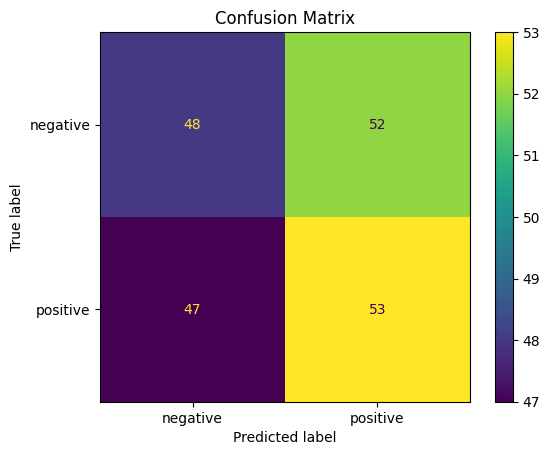

In [17]:
target_names = ["negative", "positive"]

print(classification_report(test_labels, test_preds, target_names=target_names))

cm = confusion_matrix(test_labels, test_preds)
print("Confusion Matrix:\n", cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(values_format="d")
plt.title("Confusion Matrix")
plt.show()

## 16. 직접 문장 예측해보기

학습된 모델에 새로운 리뷰 문장을 넣어서 긍정/부정을 예측할 수 있습니다.

In [18]:
def predict_review(text):
    model.eval()

    token_ids, length = encode_pad(text)
    x = torch.tensor([token_ids], dtype=torch.long).to(device)
    lengths = torch.tensor([length], dtype=torch.long).to(device)

    with torch.no_grad():
        logits = model(x, lengths)
        probs = torch.softmax(logits, dim=1).squeeze(0)
        pred = torch.argmax(probs).item()

    label_name = "positive" if pred == 1 else "negative"

    return {
        "prediction": label_name,
        "negative_prob": probs[0].item(),
        "positive_prob": probs[1].item()
    }

examples = [
    "This movie was surprisingly fun and emotionally powerful.",
    "The story was boring and the acting was terrible."
]

for text in examples:
    print(text)
    print(predict_review(text))
    print("-" * 60)

This movie was surprisingly fun and emotionally powerful.
{'prediction': 'positive', 'negative_prob': 0.36099016666412354, 'positive_prob': 0.6390098333358765}
------------------------------------------------------------
The story was boring and the acting was terrible.
{'prediction': 'positive', 'negative_prob': 0.4249749183654785, 'positive_prob': 0.5750250220298767}
------------------------------------------------------------


## 17. 정리: 두 노트북의 장점을 어떻게 합쳤는가

### 첫 번째 노트북에서 가져온 장점

1. **랜덤 시드 고정**  
   실험 결과가 매번 크게 흔들리지 않도록 유지합니다.

2. **층화 분리 사용**  
   Train / Validation / Test에 긍정과 부정 비율이 비슷하게 들어가도록 만들었습니다.

3. **Train 데이터 기준 SentencePiece 학습**  
   Test 데이터 정보가 단어사전 학습에 들어가는 데이터 누수를 막았습니다.

4. **동적 `MAX_LEN` 설정**  
   무조건 고정값을 쓰는 대신 Train 토큰 길이의 95퍼센타일을 사용해서 계산량 낭비를 줄였습니다.

5. **`lengths`와 `pack_padded_sequence` 사용**  
   Padding 토큰이 RNN/LSTM hidden state에 영향을 주지 않게 만들었습니다.

6. **학습 함수 / 평가 함수 분리**  
   코드 재사용성이 좋아지고 Test 평가 코드도 깔끔해졌습니다.

7. **Confusion Matrix 출력**  
   Accuracy만 보는 것이 아니라 어떤 클래스를 어떻게 틀렸는지 확인할 수 있습니다.

### 두 번째 노트북에서 가져온 장점

1. **단계별 설명 흐름**  
   데이터 확인 → 분리 → 토큰화 → 패딩 → Dataset → 모델 → 학습 → 평가 순서가 학습자 입장에서 따라가기 쉽습니다.

2. **Dataset 샘플 확인**  
   모델 학습 전에 입력 텐서와 라벨 모양이 맞는지 확인할 수 있습니다.

3. **Early Stopping**  
   Validation Loss가 개선되지 않으면 학습을 중단해서 과적합과 시간 낭비를 줄였습니다.

4. **직관적인 학습 로그**  
   Epoch마다 Train/Validation Loss와 Accuracy를 확인할 수 있게 했습니다.

### 추가로 개선한 부분

1. **RNN/LSTM 선택 가능 구조**  
   `MODEL_TYPE = "rnn"` 또는 `MODEL_TYPE = "lstm"`으로 쉽게 비교할 수 있습니다.

2. **Device 처리 통합**  
   GPU가 있으면 CUDA를 사용하고, 없으면 CPU로 실행합니다.

3. **가중 평균 Loss 계산**  
   Batch 개수 기준 평균이 아니라 샘플 수 기준 평균을 사용해서 마지막 작은 Batch가 결과를 왜곡하지 않게 했습니다.

4. **학습 곡선 시각화**  
   Train/Validation Loss와 Accuracy 변화를 그래프로 확인할 수 있습니다.